In [49]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)

# === Market spec ===
S0     = 50.0          # mid of 49.975 / 50.025  -- TO CONFIRM
SIGMA  = 2.51          # 251% annualized
TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY         = 4
STEPS_PER_YEAR        = TRADING_DAYS_PER_YEAR * STEPS_PER_DAY
CONTRACT_SIZE         = 3000

def weeks_to_years(w):  return w * 5 / TRADING_DAYS_PER_YEAR
def steps_for_weeks(w): return int(round(w * 5 * STEPS_PER_DAY))

T_2W = weeks_to_years(2)   # = 10/252
T_3W = weeks_to_years(3)   # = 15/252
print("σ√T (2w) =", SIGMA*np.sqrt(T_2W), "  σ√T (3w) =", SIGMA*np.sqrt(T_3W))

σ√T (2w) = 0.5000039682382212   σ√T (3w) = 0.6123772957752045


In [50]:
def bs_call(S, K, T, sigma):
    if T <= 0: return max(S-K, 0.0)
    d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*norm.cdf(d2)

def bs_put(S, K, T, sigma):
    if T <= 0: return max(K-S, 0.0)
    d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*norm.cdf(-d2) - S*norm.cdf(-d1)

In [51]:
def simulate_paths(S0, sigma, T_weeks, n_sims, seed=None):
    rng    = np.random.default_rng(seed)
    n_step = steps_for_weeks(T_weeks)
    dt     = 1.0 / STEPS_PER_YEAR
    drift  = -0.5 * sigma**2 * dt
    diff   = sigma * np.sqrt(dt)
    Z      = rng.standard_normal((n_sims, n_step))
    log_inc = drift + diff * Z
    log_p  = np.cumsum(log_inc, axis=1)
    paths  = S0 * np.exp(log_p)
    paths  = np.hstack([np.full((n_sims,1), S0), paths])  # prepend S_0
    return paths

In [52]:
def vanilla_check(n_sims=1_000_000, seed=42):
    cfg = [
        ('AC_50_C',   50, 3, 'C'), ('AC_50_P',   50, 3, 'P'),
        ('AC_35_P',   35, 3, 'P'), ('AC_40_P',   40, 3, 'P'),
        ('AC_45_P',   45, 3, 'P'), ('AC_60_C',   60, 3, 'C'),
        ('AC_50_C_2', 50, 2, 'C'), ('AC_50_P_2', 50, 2, 'P'),
    ]
    rows = []
    for name, K, w, kind in cfg:
        T = weeks_to_years(w)
        bs = bs_call(S0,K,T,SIGMA) if kind=='C' else bs_put(S0,K,T,SIGMA)
        S_T = simulate_paths(S0, SIGMA, w, n_sims, seed)[:, -1]
        po  = np.maximum(S_T-K, 0) if kind=='C' else np.maximum(K-S_T, 0)
        mc, se = po.mean(), po.std()/np.sqrt(n_sims)
        rows.append([name, K, w, kind, bs, mc, mc-bs, se, po.std()])
    return pd.DataFrame(rows, columns=['name','K','weeks','type','BS','MC','diff','MC_SE','payoff_std'])

vanilla_check()

,name,K,weeks,type,BS,MC,diff,MC_SE,payoff_std
0,AC_50_C,50,3,C,12.026949,12.041470,0.014521,0.026281,26.281017
1,AC_50_P,50,3,P,12.026949,12.009249,-0.017700,0.012609,12.608733
2,AC_35_P,35,3,P,4.336146,4.327858,-0.008288,0.006930,6.930272
3,AC_40_P,40,3,P,6.509540,6.497673,-0.011867,0.008849,8.849227
4,AC_45_P,45,3,P,9.088900,9.073756,-0.015144,0.010758,10.757981
5,AC_60_C,60,3,C,8.791792,8.803428,0.011636,0.023485,23.484578
6,AC_50_C_2,50,2,C,9.870709,9.864354,-0.006355,0.019847,19.846587
7,AC_50_P_2,50,2,P,9.870709,9.866661,-0.004048,0.010966,10.966420


In [53]:
def price_chooser(K, T_choice_w, T_expire_w, n_sims=1_000_000, seed=42):
    paths = simulate_paths(S0, SIGMA, T_expire_w, n_sims, seed)
    Sc = paths[:, steps_for_weeks(T_choice_w)]
    ST = paths[:, -1]
    payoff = np.where(Sc > K, np.maximum(ST-K, 0), np.maximum(K-ST, 0))
    return payoff.mean(), payoff.std(), payoff

# closed form: Put(T_expire) + Call(T_choice)
chooser_cf = bs_put(S0, 50, T_3W, SIGMA) + bs_call(S0, 50, T_2W, SIGMA)
ch_mc_mean, ch_std, ch_payoff = price_chooser(50, 2, 3)
print(f"Chooser  closed-form = {chooser_cf:.4f}")
print(f"Chooser  MC          = {ch_mc_mean:.4f}  (payoff std = {ch_std:.3f})")
print(f"Difference = {ch_mc_mean - chooser_cf:.4f}  (should be small)")

Chooser  closed-form = 21.8977
Chooser  MC          = 21.9024  (payoff std = 24.814)
Difference = 0.0048  (should be small)


In [54]:
def price_binary_put(K, payoff_amt, T_w, n_sims=1_000_000, seed=42):
    ST = simulate_paths(S0, SIGMA, T_w, n_sims, seed)[:, -1]
    po = np.where(ST < K, payoff_amt, 0.0)
    return po.mean(), po.std(), po

T = T_3W
d2 = (np.log(S0/40) - 0.5*SIGMA**2*T) / (SIGMA*np.sqrt(T))
bp_cf = 10 * norm.cdf(-d2)
bp_mc_mean, bp_std, bp_payoff = price_binary_put(40, 10, 3)
print(f"BinaryPut CF = {bp_cf:.4f},  MC = {bp_mc_mean:.4f}")

BinaryPut CF = 4.7679,  MC = 4.7631


In [55]:
def price_knockout_put(K, B, T_w, n_sims=1_000_000, seed=42):
    paths = simulate_paths(S0, SIGMA, T_w, n_sims, seed)
    breached = np.any(paths < B, axis=1)        # strict "<"  (per the wording)
    ST       = paths[:, -1]
    po       = np.where(breached, 0.0, np.maximum(K-ST, 0))
    return po.mean(), po.std(), po, breached

ko_mean, ko_std, ko_payoff, breached = price_knockout_put(45, 35, 3)
print(f"KO put  MC fair = {ko_mean:.5f}   payoff std = {ko_std:.4f}")
print(f"P(no KO)        = {(~breached).mean():.4f}")
print(f"E[(45-S_T)+ | no KO] = {ko_payoff[~breached].mean():.4f}")
print(f"MC SE           = {ko_std/np.sqrt(len(ko_payoff)):.5f}")

# Robustness: re-run with 5 different seeds
seeds = [1,2,3,4,5]
fairs = [price_knockout_put(45,35,3,n_sims=500_000,seed=s)[0] for s in seeds]
print("Across seeds:", fairs, "mean=", np.mean(fairs), "spread=", max(fairs)-min(fairs))

KO put  MC fair = 0.20582   payoff std = 1.0861
P(no KO)        = 0.3862
E[(45-S_T)+ | no KO] = 0.5329
MC SE           = 0.00109
Across seeds: [np.float64(0.20995643520807045), np.float64(0.20711999624303123), np.float64(0.20702369464904938), np.float64(0.2092966262156191), np.float64(0.20625238610587374)] mean= 0.2079298276843288 spread= 0.0037040491021967104


In [56]:
market = {
    'AC':         dict(bid=49.975, ask=50.025, vol=200),
    'AC_50_P':    dict(bid=12.00,  ask=12.05,  vol=50),
    'AC_50_C':    dict(bid=12.00,  ask=12.05,  vol=50),
    'AC_35_P':    dict(bid=4.33,   ask=4.35,   vol=50),
    'AC_40_P':    dict(bid=6.50,   ask=6.55,   vol=50),
    'AC_45_P':    dict(bid=9.05,   ask=9.10,   vol=50),
    'AC_60_C':    dict(bid=8.80,   ask=8.85,   vol=50),
    'AC_50_P_2':  dict(bid=9.70,   ask=9.75,   vol=50),
    'AC_50_C_2':  dict(bid=9.70,   ask=9.75,   vol=50),
    'AC_50_CO':   dict(bid=22.20,  ask=22.30,  vol=50),
    'AC_40_BP':   dict(bid=5.00,   ask=5.10,   vol=50),
    'AC_45_KO':   dict(bid=0.150,  ask=0.175,  vol=500),
}

fair = {
    'AC':         S0,
    'AC_50_P':    bs_put( S0, 50, T_3W, SIGMA),
    'AC_50_C':    bs_call(S0, 50, T_3W, SIGMA),
    'AC_35_P':    bs_put( S0, 35, T_3W, SIGMA),
    'AC_40_P':    bs_put( S0, 40, T_3W, SIGMA),
    'AC_45_P':    bs_put( S0, 45, T_3W, SIGMA),
    'AC_60_C':    bs_call(S0, 60, T_3W, SIGMA),
    'AC_50_P_2':  bs_put( S0, 50, T_2W, SIGMA),
    'AC_50_C_2':  bs_call(S0, 50, T_2W, SIGMA),
    'AC_50_CO':   chooser_cf,
    'AC_40_BP':   bp_cf,
    'AC_45_KO':   ko_mean,
}

rows = []
for k,m in market.items():
    f = fair[k]
    buy_e  = f - m['ask']
    sell_e = m['bid'] - f
    if buy_e > sell_e and buy_e > 0:
        action, edge, price = 'BUY',  buy_e,  m['ask']
    elif sell_e > 0:
        action, edge, price = 'SELL', sell_e, m['bid']
    else:
        action, edge, price = 'NONE', max(buy_e, sell_e), np.nan
    pos = m['vol'] if action=='BUY' else (-m['vol'] if action=='SELL' else 0)
    rows.append(dict(instrument=k, fair=round(f,4), bid=m['bid'], ask=m['ask'],
                     vol=m['vol'], buy_edge=round(buy_e,4), sell_edge=round(sell_e,4),
                     action=action, edge_per=round(edge,4),
                     position=pos, price=price,
                     expected_pnl=round(edge*m['vol']*CONTRACT_SIZE if action!='NONE' else 0, 2)))
edges = pd.DataFrame(rows)
edges_sorted = edges.sort_values('expected_pnl', ascending=False)
print(edges_sorted.to_string(index=False))
print("Total expected PnL: $", edges['expected_pnl'].sum())

instrument    fair    bid    ask  vol  buy_edge  sell_edge action  edge_per  position  price  expected_pnl
  AC_45_KO  0.2058  0.150  0.175  500    0.0308    -0.0558    BUY    0.0308       500  0.175      46227.58
  AC_50_CO 21.8977 22.200 22.300   50   -0.4023     0.3023   SELL    0.3023       -50 22.200      45351.22
  AC_40_BP  4.7679  5.000  5.100   50   -0.3321     0.2321   SELL    0.2321       -50  5.000      34808.22
 AC_50_P_2  9.8707  9.700  9.750   50    0.1207    -0.1707    BUY    0.1207        50  9.750      18106.39
 AC_50_C_2  9.8707  9.700  9.750   50    0.1207    -0.1707    BUY    0.1207        50  9.750      18106.39
   AC_60_C  8.7918  8.800  8.850   50   -0.0582     0.0082   SELL    0.0082       -50  8.800       1231.25
   AC_50_P 12.0269 12.000 12.050   50   -0.0231    -0.0269   NONE   -0.0231         0    NaN          0.00
        AC 50.0000 49.975 50.025  200   -0.0250    -0.0250   NONE   -0.0250         0    NaN          0.00
   AC_35_P  4.3361  4.330  4.350   50

In [57]:
def all_payoffs(n_sims=200_000, seed=2024):
    paths = simulate_paths(S0, SIGMA, 3, n_sims, seed)
    Sc, ST = paths[:, steps_for_weeks(2)], paths[:, -1]
    breach = np.any(paths < 35, axis=1)
    out = pd.DataFrame()
    out['AC']        = ST
    out['AC_50_P']   = np.maximum(50-ST, 0)
    out['AC_50_C']   = np.maximum(ST-50, 0)
    out['AC_35_P']   = np.maximum(35-ST, 0)
    out['AC_40_P']   = np.maximum(40-ST, 0)
    out['AC_45_P']   = np.maximum(45-ST, 0)
    out['AC_60_C']   = np.maximum(ST-60, 0)
    out['AC_50_P_2'] = np.maximum(50-Sc, 0)
    out['AC_50_C_2'] = np.maximum(Sc-50, 0)
    out['AC_50_CO']  = np.where(Sc > 50, np.maximum(ST-50,0), np.maximum(50-ST,0))
    out['AC_40_BP']  = np.where(ST < 40, 10.0, 0.0)
    out['AC_45_KO']  = np.where(breach, 0.0, np.maximum(45-ST, 0))
    return out

P = all_payoffs(200_000)
positions = {r['instrument']: r['position'] for _,r in edges.iterrows()}
prices    = {r['instrument']: (0 if pd.isna(r['price']) else r['price']) for _,r in edges.iterrows()}

# Per-path PnL of the chosen portfolio
pnl_path = sum(positions[c] * (P[c] - prices[c]) for c in P.columns) * CONTRACT_SIZE
mu  = pnl_path.mean()
sig = pnl_path.std()
print(f"Per-path portfolio PnL: mean={mu:,.0f}  std={sig:,.0f}")
print(f"With 100-sim grading:   mean={mu:,.0f}  std={sig/np.sqrt(100):,.0f}")
print(f"Z-score (mean / std)  = {mu / (sig/np.sqrt(100)):.2f}")
print(f"P(realized PnL > 0)   ≈ {norm.cdf(mu / (sig/np.sqrt(100))):.3f}")

Per-path portfolio PnL: mean=165,761  std=5,848,475
With 100-sim grading:   mean=165,761  std=584,848
Z-score (mean / std)  = 0.28
P(realized PnL > 0)   ≈ 0.612


In [58]:
def fair_recompute(S0_, sigma_):
    return {
        'AC_60_C':   bs_call(S0_, 60, T_3W, sigma_),
        'AC_50_C_2': bs_call(S0_, 50, T_2W, sigma_),
        'AC_50_P_2': bs_put( S0_, 50, T_2W, sigma_),
        'AC_50_CO':  bs_put( S0_, 50, T_3W, sigma_) + bs_call(S0_, 50, T_2W, sigma_),
    }
for dS in [-0.1, 0, 0.1]:
    for dV in [-0.05, 0, 0.05]:
        f = fair_recompute(S0+dS, SIGMA+dV)
        print(f"S={S0+dS:.2f} σ={SIGMA+dV:.2f} | "
              f"60C={f['AC_60_C']:.3f}  C_2={f['AC_50_C_2']:.3f}  "
              f"CO={f['AC_50_CO']:.3f}")

S=49.90 σ=2.46 | 60C=8.499  C_2=9.618  CO=21.451
S=49.90 σ=2.51 | 60C=8.742  C_2=9.811  CO=21.876
S=49.90 σ=2.56 | 60C=8.984  C_2=10.003  CO=22.300
S=50.00 σ=2.46 | 60C=8.548  C_2=9.678  CO=21.473
S=50.00 σ=2.51 | 60C=8.792  C_2=9.871  CO=21.898
S=50.00 σ=2.56 | 60C=9.035  C_2=10.063  CO=22.322
S=50.10 σ=2.46 | 60C=8.598  C_2=9.738  CO=21.494
S=50.10 σ=2.51 | 60C=8.842  C_2=9.931  CO=21.920
S=50.10 σ=2.56 | 60C=9.086  C_2=10.123  CO=22.345


In [59]:
final = edges[edges['action']!='NONE'][['instrument','action','vol','price','fair','edge_per','expected_pnl']]
final = final.rename(columns={'vol':'qty'})
print("===== ORDERS TO SUBMIT =====")
print(final.to_string(index=False))
print(f"\nTotal expected PnL: ${final['expected_pnl'].sum():,.0f}")

===== ORDERS TO SUBMIT =====
instrument action  qty  price    fair  edge_per  expected_pnl
   AC_60_C   SELL   50  8.800  8.7918    0.0082       1231.25
 AC_50_P_2    BUY   50  9.750  9.8707    0.1207      18106.39
 AC_50_C_2    BUY   50  9.750  9.8707    0.1207      18106.39
  AC_50_CO   SELL   50 22.200 21.8977    0.3023      45351.22
  AC_40_BP   SELL   50  5.000  4.7679    0.2321      34808.22
  AC_45_KO    BUY  500  0.175  0.2058    0.0308      46227.58

Total expected PnL: $163,831


In [60]:
from scipy.stats import t as t_dist

print("="*70)
print("KO PUT - MULTI-SEED ROBUSTNESS CHECK")
print("="*70)

n_seeds = 30
n_per_seed = 500_000
ko_fairs_per_seed = []
for seed in range(n_seeds):
    fair, _, _, _ = price_knockout_put(45, 35, 3, n_sims=n_per_seed, seed=seed)
    ko_fairs_per_seed.append(fair)

ko_arr = np.array(ko_fairs_per_seed)
ko_mean = ko_arr.mean()
ko_std  = ko_arr.std(ddof=1)
ci_half = t_dist.ppf(0.975, n_seeds-1) * ko_std / np.sqrt(n_seeds)
ci_lo, ci_hi = ko_mean - ci_half, ko_mean + ci_half

print(f"  Seeds: {n_seeds} x {n_per_seed:,} sims = {n_seeds*n_per_seed:,} total paths")
print(f"  Mean fair:    {ko_mean:.5f}")
print(f"  Std seeds:    {ko_std:.5f}  (per-seed; SE on mean = {ko_std/np.sqrt(n_seeds):.5f})")
print(f"  Min/Max:      [{ko_arr.min():.5f}, {ko_arr.max():.5f}]")
print(f"  95% CI mean:  [{ci_lo:.5f}, {ci_hi:.5f}]")
print(f"\n  Buy edge (ask=0.175):   {ko_mean-0.175:+.5f}")
print(f"  95% CI of edge:         [{ci_lo-0.175:+.5f}, {ci_hi-0.175:+.5f}]")
print(f"  Edge significantly > 0: {ci_lo > 0.175}")

# σ sensitivity (in case 2.51 is slightly off)
def quick_ko(sig, n_sims=300_000, seed=42):
    rng = np.random.default_rng(seed)
    n_step = steps_for_weeks(3); dt = 1.0/STEPS_PER_YEAR
    drift = -0.5*sig**2*dt
    Z = rng.standard_normal((n_sims, n_step))
    paths = S0 * np.exp(np.cumsum(drift + sig*np.sqrt(dt)*Z, axis=1))
    paths = np.hstack([np.full((n_sims,1), S0), paths])
    breached = np.any(paths < 35, axis=1)
    return np.where(breached, 0.0, np.maximum(45 - paths[:,-1], 0)).mean()

print("\n  σ sensitivity:")
for s in [2.30, 2.40, 2.45, 2.51, 2.56, 2.60, 2.70, 2.80]:
    f = quick_ko(s)
    print(f"    σ={s:.2f}:  fair={f:.4f}   edge vs 0.175 = {f-0.175:+.4f}")

KO_FAIR_BEST = ko_mean

KO PUT - MULTI-SEED ROBUSTNESS CHECK
  Seeds: 30 x 500,000 sims = 15,000,000 total paths
  Mean fair:    0.20648
  Std seeds:    0.00175  (per-seed; SE on mean = 0.00032)
  Min/Max:      [0.20233, 0.20996]
  95% CI mean:  [0.20582, 0.20713]

  Buy edge (ask=0.175):   +0.03148
  95% CI of edge:         [+0.03082, +0.03213]
  Edge significantly > 0: True

  σ sensitivity:
    σ=2.30:  fair=0.2505   edge vs 0.175 = +0.0755
    σ=2.40:  fair=0.2262   edge vs 0.175 = +0.0512
    σ=2.45:  fair=0.2159   edge vs 0.175 = +0.0409
    σ=2.51:  fair=0.2064   edge vs 0.175 = +0.0314
    σ=2.56:  fair=0.1972   edge vs 0.175 = +0.0222
    σ=2.60:  fair=0.1914   edge vs 0.175 = +0.0164
    σ=2.70:  fair=0.1777   edge vs 0.175 = +0.0027
    σ=2.80:  fair=0.1625   edge vs 0.175 = -0.0125


In [61]:
print("\n" + "="*70)
print("PAYOFF COVARIANCE MATRIX (common-path MC)")
print("="*70)

N_BIG = 500_000
P_df = all_payoffs(N_BIG, seed=2024)
P_arr = P_df.values
emp_means = P_arr.mean(axis=0)
Sigma = np.cov(P_arr, rowvar=False)

# Use BS / closed-form for fair values where possible (more accurate than MC)
def d2(S, K, sigma, T):
    return (np.log(S/K) - 0.5*sigma**2*T) / (sigma*np.sqrt(T))

bs_fairs = {
    'AC':         S0,
    'AC_50_P':    bs_put( S0, 50, T_3W, SIGMA),
    'AC_50_C':    bs_call(S0, 50, T_3W, SIGMA),
    'AC_35_P':    bs_put( S0, 35, T_3W, SIGMA),
    'AC_40_P':    bs_put( S0, 40, T_3W, SIGMA),
    'AC_45_P':    bs_put( S0, 45, T_3W, SIGMA),
    'AC_60_C':    bs_call(S0, 60, T_3W, SIGMA),
    'AC_50_P_2':  bs_put( S0, 50, T_2W, SIGMA),
    'AC_50_C_2':  bs_call(S0, 50, T_2W, SIGMA),
    'AC_50_CO':   bs_put(S0, 50, T_3W, SIGMA) + bs_call(S0, 50, T_2W, SIGMA),
    'AC_40_BP':   10 * norm.cdf(-d2(S0, 40, SIGMA, T_3W)),
    'AC_45_KO':   KO_FAIR_BEST,
}
instruments = list(P_df.columns)
fair_values = np.array([bs_fairs[c] for c in instruments])

print("Instrument        BS-fair     MC-fair    diff")
for c, b, e in zip(instruments, fair_values, emp_means):
    print(f"  {c:<12}  {b:8.4f}   {e:8.4f}   {(e-b):+.4f}")

# Correlation
stds = np.sqrt(np.diag(Sigma))
corr = Sigma / np.outer(stds, stds)
print("\nPayoff correlation (rounded):")
print(pd.DataFrame(corr, index=instruments, columns=instruments).round(2).to_string())


PAYOFF COVARIANCE MATRIX (common-path MC)
Instrument        BS-fair     MC-fair    diff
  AC             50.0000    50.0123   +0.0123
  AC_50_P        12.0269    12.0268   -0.0002
  AC_50_C        12.0269    12.0391   +0.0122
  AC_35_P         4.3361     4.3438   +0.0076
  AC_40_P         6.5095     6.5146   +0.0051
  AC_45_P         9.0889     9.0905   +0.0016
  AC_60_C         8.7918     8.7991   +0.0073
  AC_50_P_2       9.8707     9.8648   -0.0059
  AC_50_C_2       9.8707     9.8862   +0.0155
  AC_50_CO       21.8977    21.9184   +0.0207
  AC_40_BP        4.7679     4.7635   -0.0045
  AC_45_KO        0.2065     0.2037   -0.0028

Payoff correlation (rounded):
             AC  AC_50_P  AC_50_C  AC_35_P  AC_40_P  AC_45_P  AC_60_C  AC_50_P_2  AC_50_C_2  AC_50_CO  AC_40_BP  AC_45_KO
AC         1.00    -0.71     0.94    -0.56    -0.62    -0.67     0.90      -0.59       0.74      0.62     -0.67     -0.06
AC_50_P   -0.71     1.00    -0.44     0.91     0.96     0.99    -0.36       0.77    

In [62]:
import cvxpy as cp

print("\n" + "="*70)
print("MEAN-VARIANCE OPTIMIZATION  (sweep over risk aversion λ)")
print("="*70)

M = len(instruments)
bids = np.array([market[c]['bid'] for c in instruments])
asks = np.array([market[c]['ask'] for c in instruments])
vols = np.array([market[c]['vol'] for c in instruments])

p_buy  = cp.Variable(M, nonneg=True)
p_sell = cp.Variable(M, nonneg=True)
position = p_buy - p_sell

buy_edge  = fair_values - asks
sell_edge = bids - fair_values
E_pnl = CONTRACT_SIZE * (buy_edge @ p_buy + sell_edge @ p_sell)

L = np.linalg.cholesky(Sigma + 1e-8*np.eye(M))
realized_std = (CONTRACT_SIZE / 10.0) * cp.norm(L.T @ position)   # 1/sqrt(100)

constraints = [p_buy <= vols, p_sell <= vols]

lambdas = np.concatenate([[0.0], np.logspace(-3, 1.5, 60)])
front = []
for lam in lambdas:
    obj  = cp.Maximize(E_pnl - lam * realized_std)
    prob = cp.Problem(obj, constraints)
    try:
        prob.solve(solver=cp.SCS, verbose=False)
    except Exception:
        continue
    if prob.status not in ['optimal', 'optimal_inaccurate']:
        continue
    front.append(dict(
        lam=lam,
        E=float(E_pnl.value),
        std=float(realized_std.value),
        pos=position.value.copy(),
        p_buy=p_buy.value.copy(),
        p_sell=p_sell.value.copy(),
    ))

df_front = pd.DataFrame(front)
df_front['sharpe'] = df_front['E'] / df_front['std']
df_front['p_pos']  = norm.cdf(df_front['sharpe'])

# Print every 5th row
print(f"\n{'λ':>10} {'E[PnL] $':>12} {'Std $':>12} {'Sharpe':>8} {'P(>0)':>8}")
for i, r in df_front.iterrows():
    if i % 5 == 0 or i == len(df_front)-1:
        print(f"{r['lam']:>10.4f} {r['E']:>12,.0f} {r['std']:>12,.0f} {r['sharpe']:>8.3f} {r['p_pos']:>8.3f}")


MEAN-VARIANCE OPTIMIZATION  (sweep over risk aversion λ)


C:\Users\steve\AppData\Local\Temp\ipykernel_26760\2098109981.py:31: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, verbose=False)



         λ     E[PnL] $        Std $   Sharpe    P(>0)
    0.0000      164,663      586,193    0.281    0.611
    0.0020      164,822      588,332    0.280    0.610
    0.0049      164,196      446,778    0.368    0.643
    0.0117      163,590      343,551    0.476    0.683
    0.0281      163,284      331,361    0.493    0.689
    0.0677      160,970      270,688    0.595    0.724
    0.1629      157,634      246,267    0.640    0.739
    0.3919      147,727      201,439    0.733    0.768
    0.9431       41,928       22,992    1.824    0.966
    2.2695            0            0      nan      nan
    5.4612            0            0      nan      nan
   13.1415            0            0      nan      nan
   31.6228            0            0      nan      nan


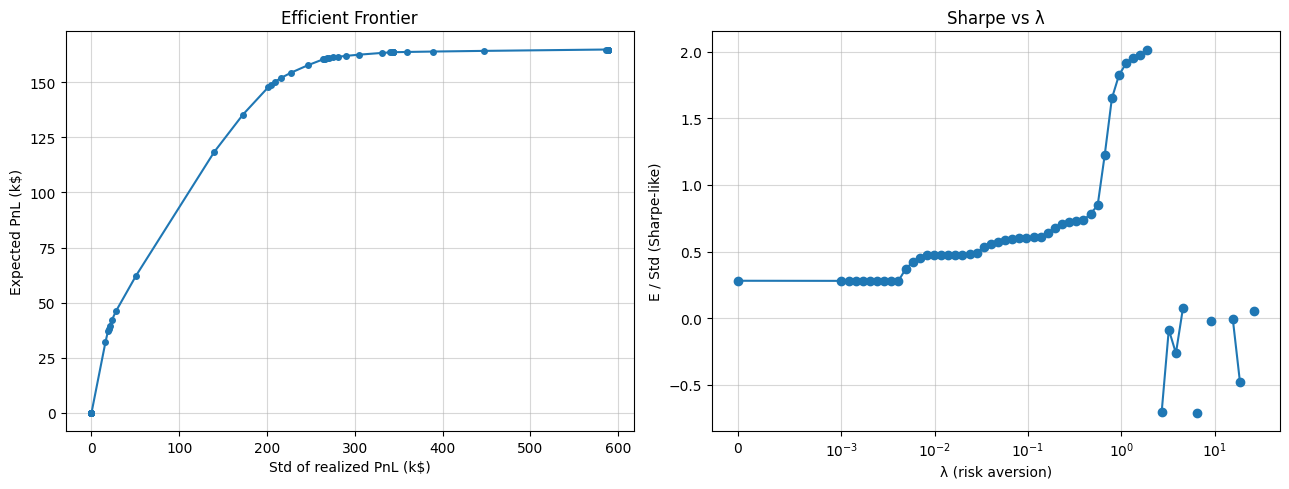


Strategy                  λ       E[PnL] $          Std $   Sharpe    P(>0)
Max E (orig)          0.002        164,822        588,332    0.280    0.610
Max Sharpe            1.904         32,172         15,963    2.015    0.978
85% E, min Std        0.392        147,727        201,439    0.733    0.768
70% E, min Std        0.557        118,364        139,868    0.846    0.801
50% E, min Std        0.557        118,364        139,868    0.846    0.801


In [63]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
axs[0].plot(df_front['std']/1e3, df_front['E']/1e3, 'o-', ms=4)
axs[0].set_xlabel('Std of realized PnL (k$)')
axs[0].set_ylabel('Expected PnL (k$)')
axs[0].set_title('Efficient Frontier')
axs[0].grid(alpha=0.5)

axs[1].plot(df_front['lam'], df_front['sharpe'], 'o-')
axs[1].set_xscale('symlog', linthresh=1e-3)
axs[1].set_xlabel('λ (risk aversion)')
axs[1].set_ylabel('E / Std (Sharpe-like)')
axs[1].set_title('Sharpe vs λ')
axs[1].grid(alpha=0.5)
plt.tight_layout(); plt.show()

# Operating points
idx_maxE   = df_front['E'].idxmax()
idx_sharpe = df_front['sharpe'].idxmax()
target_85  = 0.85 * df_front['E'].max()
target_70  = 0.70 * df_front['E'].max()
target_50  = 0.50 * df_front['E'].max()
idx_85 = df_front[df_front['E']>=target_85]['std'].idxmin()
idx_70 = df_front[df_front['E']>=target_70]['std'].idxmin()
idx_50 = df_front[df_front['E']>=target_50]['std'].idxmin()

strats = {
    'Max E (orig)':   df_front.iloc[idx_maxE],
    'Max Sharpe':     df_front.iloc[idx_sharpe],
    '85% E, min Std': df_front.iloc[idx_85],
    '70% E, min Std': df_front.iloc[idx_70],
    '50% E, min Std': df_front.iloc[idx_50],
}
print(f"\n{'Strategy':<18} {'λ':>8} {'E[PnL] $':>14} {'Std $':>14} {'Sharpe':>8} {'P(>0)':>8}")
for n, s in strats.items():
    print(f"{n:<18} {s['lam']:>8.3f} {s['E']:>14,.0f} {s['std']:>14,.0f} {s['sharpe']:>8.3f} {norm.cdf(s['sharpe']):>8.3f}")

In [64]:
def positions_table(s):
    p_cont = s['pos']
    p_int  = np.clip(np.round(p_cont).astype(int), -vols, vols)
    actions = ['BUY' if p>0 else ('SELL' if p<0 else 'NONE') for p in p_int]
    prices  = np.where(p_int>0, asks, np.where(p_int<0, bids, np.nan))
    edges   = np.where(p_int>0, fair_values-asks,
              np.where(p_int<0, bids-fair_values, 0))
    pnls    = np.abs(p_int) * edges * CONTRACT_SIZE          # ← fixed
    return pd.DataFrame({
        'instrument': instruments, 'fair': fair_values.round(4),
        'bid': bids, 'ask': asks, 'vol': vols,
        'p_cont': p_cont.round(2), 'p_int': p_int,
        'action': actions, 'price': prices,
        'edge_per': np.round(edges, 4),
        'expected_pnl': np.round(pnls, 0),
    })

# Sanity: no simultaneous buy and sell
for n, s in strats.items():
    both = (s['p_buy'] > 0.01) & (s['p_sell'] > 0.01)
    if both.any():
        print(f"WARNING ({n}): simultaneous buy+sell on {[instruments[i] for i,b in enumerate(both) if b]}")

# Side-by-side comparison
combo = pd.DataFrame({'instrument': instruments,
                      'bid': bids, 'ask': asks, 'fair': fair_values.round(3),
                      'vol': vols})
for n, s in strats.items():
    p_int = np.clip(np.round(s['pos']).astype(int), -vols, vols)
    combo[n] = p_int
print("\n=== Position comparison (signed quantities) ===")
print(combo.to_string(index=False))

# Detailed per-strategy
for n, s in strats.items():
    print(f"\n{'='*80}\n=== {n} ===\n{'='*80}")
    t = positions_table(s)
    print(t[t['p_int']!=0].to_string(index=False))
    print(f"Total expected PnL: ${t['expected_pnl'].sum():,.0f}")


=== Position comparison (signed quantities) ===
instrument    bid    ask   fair  vol  Max E (orig)  Max Sharpe  85% E, min Std  70% E, min Std  50% E, min Std
        AC 49.975 50.025 50.000  200             0           1               0               0               0
   AC_50_P 12.000 12.050 12.027   50             0           0               0              12              12
   AC_50_C 12.000 12.050 12.027   50             0           2              42              45              45
   AC_35_P  4.330  4.350  4.336   50             0         -48               0             -18             -18
   AC_40_P  6.500  6.550  6.510   50             0           0               0               0               0
   AC_45_P  9.050  9.100  9.089   50             0          50              49              50              50
   AC_60_C  8.800  8.850  8.792   50           -50          -1               0               0               0
 AC_50_P_2  9.700  9.750  9.871   50            50           2 


VALIDATION ON UNSEEN PATHS  (bootstrap of 100-sim averaging)

Strategy                 Mean $        Std $   P(>0)     5%-VaR $       95th $
Max E (orig)            160,926      584,795   0.628      857,668    1,067,070
Max Sharpe               32,060       16,241   0.978       -5,641       58,836
85% E, min Std          146,947      202,539   0.760      171,265      494,477
70% E, min Std          119,173      141,179   0.799      105,553      358,658
50% E, min Std          119,173      141,179   0.799      105,553      358,658


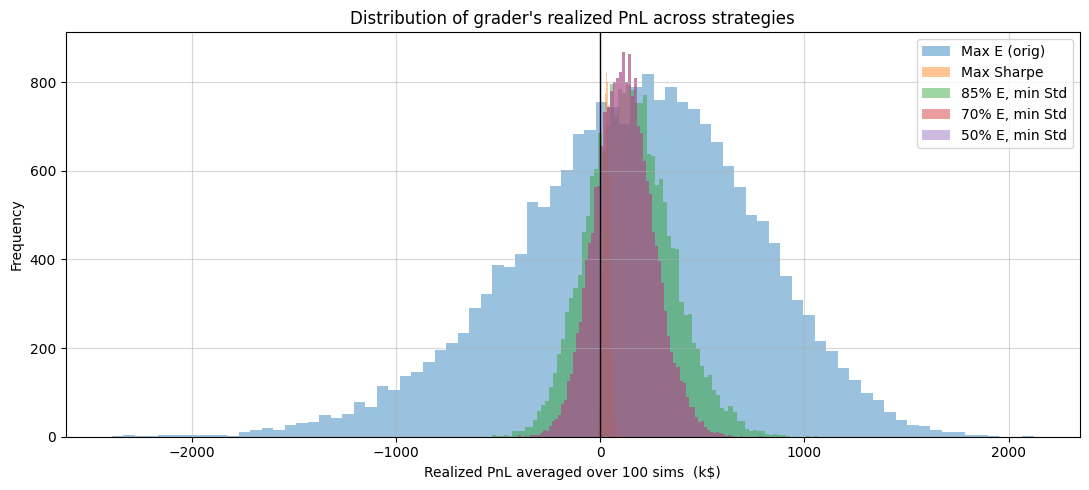

In [65]:
print("\n" + "="*70)
print("VALIDATION ON UNSEEN PATHS  (bootstrap of 100-sim averaging)")
print("="*70)

P_val = all_payoffs(200_000, seed=2025).values

def evaluate(s, n_runs=20000, n_per_run=100, rng_seed=99):
    p_int  = np.clip(np.round(s['pos']).astype(int), -vols, vols)
    prices = np.where(p_int>0, asks, np.where(p_int<0, bids, 0))
    per_path = (P_val - prices) @ p_int * CONTRACT_SIZE
    rng = np.random.default_rng(rng_seed)
    idx = rng.choice(P_val.shape[0], (n_runs, n_per_run))
    realized = per_path[idx].mean(axis=1)
    return dict(
        mean=realized.mean(), std=realized.std(),
        p_pos=(realized>0).mean(),
        p5=np.percentile(realized,5),  p95=np.percentile(realized,95),
        per_path=per_path, realized=realized,
    )

print(f"\n{'Strategy':<18} {'Mean $':>12} {'Std $':>12} {'P(>0)':>7} {'5%-VaR $':>12} {'95th $':>12}")
for n, s in strats.items():
    r = evaluate(s)
    print(f"{n:<18} {r['mean']:>12,.0f} {r['std']:>12,.0f} {r['p_pos']:>7.3f} "
          f"{-r['p5']:>12,.0f} {r['p95']:>12,.0f}")

# Histogram comparison
fig, ax = plt.subplots(figsize=(11, 5))
for n, s in strats.items():
    r = evaluate(s)
    ax.hist(r['realized']/1000, bins=80, alpha=0.45, label=n)
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('Realized PnL averaged over 100 sims  (k$)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of grader\'s realized PnL across strategies')
ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout(); plt.show()

In [66]:
print("\n" + "="*70)
print("FINAL RECOMMENDATION")
print("="*70)

# Pick whichever fits your appetite. By default use Max Sharpe.
RECOMMENDED = 'Max Sharpe'        # change to '85% E, min Std' if you want more dollars
s = strats[RECOMMENDED]
t = positions_table(s)
t_nz = t[t['p_int']!=0].copy()
t_nz['qty'] = t_nz['p_int'].abs()
out = t_nz[['instrument','action','qty','price','fair','edge_per','expected_pnl']]

print(f"\nStrategy:    {RECOMMENDED}")
print(f"E[PnL]:      ${s['E']:,.0f}")
print(f"Std (real):  ${s['std']:,.0f}")
print(f"Sharpe:      {s['sharpe']:.2f}    P(profit) ≈ {norm.cdf(s['sharpe']):.1%}")
print("\nORDERS TO SUBMIT")
print(out.to_string(index=False))


FINAL RECOMMENDATION

Strategy:    Max Sharpe
E[PnL]:      $32,172
Std (real):  $15,963
Sharpe:      2.02    P(profit) ≈ 97.8%

ORDERS TO SUBMIT
instrument action  qty  price    fair  edge_per  expected_pnl
        AC    BUY    1 50.025 50.0000   -0.0250         -75.0
   AC_50_C    BUY    2 12.050 12.0269   -0.0231        -138.0
   AC_35_P   SELL   48  4.330  4.3361   -0.0061        -885.0
   AC_45_P    BUY   50  9.100  9.0889   -0.0111       -1665.0
   AC_60_C   SELL    1  8.800  8.7918    0.0082          25.0
 AC_50_P_2    BUY    2  9.750  9.8707    0.1207         724.0
  AC_50_CO   SELL    2 22.200 21.8977    0.3023        1814.0
  AC_40_BP   SELL   44  5.000  4.7679    0.2321       30631.0
  AC_45_KO    BUY   11  0.175  0.2065    0.0315        1039.0
